# **1. IMPORT LIBRARY**

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **2. MOUNT GOOGLE DRIVE**

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **3. PATH DATASET**

In [3]:
dataset_path = "/content/drive/MyDrive/Comvis - UTS KNN/Dataset Banana and Carrot"

categories = ["banana", "carrot"]

# **4. CEK JUMLAH DATA PER KELAS**

In [4]:
for cat in categories:
    folder = os.path.join(dataset_path, cat)
    print(cat, ":", len(os.listdir(folder)), "images")

banana : 150 images
carrot : 150 images


# **5. EKSTRAKSI FITUR CITRA WARNA HSV + GRAY**

In [5]:
data = []
labels = []
paths = []

for label in categories:
    folder = os.path.join(dataset_path, label)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        try:
            img = cv2.imread(path)
            img = cv2.resize(img, (128,128))

            # Blur (biar warna lebih stabil)
            img = cv2.GaussianBlur(img, (5,5), 0)

            # HSV
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

            # Histogram
            hist_h = cv2.calcHist([hsv], [0], None, [16], [0,180]).flatten()
            hist_s = cv2.calcHist([hsv], [1], None, [16], [0,256]).flatten()
            hist_v = cv2.calcHist([hsv], [2], None, [16], [0,256]).flatten()

            # Normalisasi
            hist_h /= (hist_h.sum() + 1e-6)
            hist_s /= (hist_s.sum() + 1e-6)
            hist_v /= (hist_v.sum() + 1e-6)

            # =========================
            # GRAYSCALE
            # =========================
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            g_mean = np.mean(gray)
            g_std = np.std(gray)

            # =========================
            # GABUNG FITUR
            # =========================
            feature = np.concatenate([hist_h, hist_s, hist_v, [g_mean, g_std]])

            data.append(feature)
            labels.append(1 if label == "banana" else 0)
            paths.append(path)

        except:
            continue

print("Total data:", len(data))

Total data: 300


# **6. SIMPAN KE CSV**

In [6]:
columns = []

# H histogram
for i in range(16):
    columns.append(f"H_{i}")

# S histogram
for i in range(16):
    columns.append(f"S_{i}")

# V histogram
for i in range(16):
    columns.append(f"V_{i}")

# Gray
columns += ["GrayMean", "GrayStd"]

df = pd.DataFrame(data, columns=columns)
df["Label"] = labels
df["Path"] = paths

csv_path = "/content/drive/MyDrive/Comvis - UTS KNN/Dataset Banana and Carrot/data_fitur.csv"

df.to_csv(csv_path, index=False)

print("CSV saved:", csv_path)
df.head()

CSV saved: /content/drive/MyDrive/Comvis - UTS KNN/Dataset Banana and Carrot/data_fitur.csv


,H_0,H_1,H_2,H_3,H_4,H_5,H_6,H_7,H_8,H_9,...,V_10,V_11,V_12,V_13,V_14,V_15,GrayMean,GrayStd,Label,Path
0,0.079224,0.145386,0.002625,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001465,...,0.000732,0.009277,0.040039,0.573853,0.360291,0.015381,214.551392,12.946057,1,/content/drive/MyDrive/Comvis - UTS KNN/Datase...
1,0.000793,0.118042,0.880249,0.000427,0.000366,0.000122,0.000000,0.000000,0.000000,0.000000,...,0.001099,0.001770,0.003418,0.020874,0.076660,0.894165,208.319153,13.181515,1,/content/drive/MyDrive/Comvis - UTS KNN/Datase...
2,0.506714,0.016968,0.016174,0.163025,0.246582,0.030396,0.008789,0.001465,0.005554,0.000427,...,0.047241,0.070251,0.091614,0.084229,0.082336,0.556824,216.917480,47.534516,1,/content/drive/MyDrive/Comvis - UTS KNN/Datase...
3,0.000427,0.028442,0.358398,0.038757,0.227417,0.245544,0.092590,0.008423,0.000000,0.000000,...,0.028015,0.022583,0.025513,0.046387,0.066650,0.155884,106.546936,78.343519,1,/content/drive/MyDrive/Comvis - UTS KNN/Datase...
4,0.000000,0.095825,0.251648,0.097778,0.554382,0.000366,0.000000,0.000000,0.000000,0.000000,...,0.057983,0.027222,0.022156,0.030090,0.042297,0.161987,118.574036,54.295860,1,/content/drive/MyDrive/Comvis - UTS KNN/Datase...


# **7. LOAD DATA**

In [7]:
df = pd.read_csv("/content/drive/MyDrive/Comvis - UTS KNN/Dataset Banana and Carrot/data_fitur.csv")

X = df.drop(columns=["Label", "Path"])
y = df["Label"]

# **8. SPLIT DATA**

In [8]:
X_train, X_test, y_train, y_test, path_train, path_test = train_test_split(
    X, y, df["Path"], test_size=0.2, random_state=42
)

# **9. TRAIN MODEL (KNN)**

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# NORMALISASI
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL FINAL (K = 3)
model = KNeighborsClassifier(n_neighbors=3, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3, weights='distance')

# **10. PREDIKSI**

In [10]:
y_pred = model.predict(X_test)

# **11. AKURASI & REPORT**

In [11]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7666666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.81      0.78        31
           1       0.78      0.72      0.75        29

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



# **12. CONFUSION MATRIX**

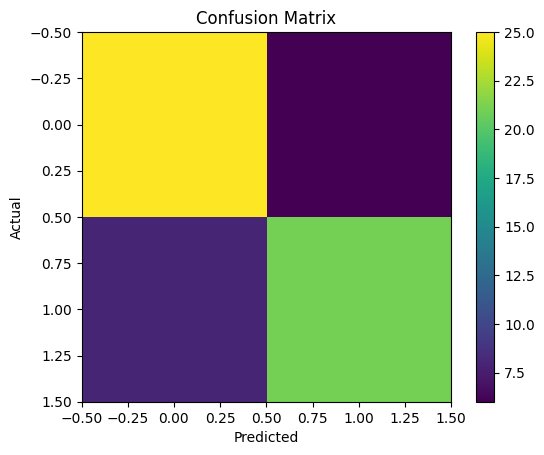

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **13. VISUALISASI HASIL**

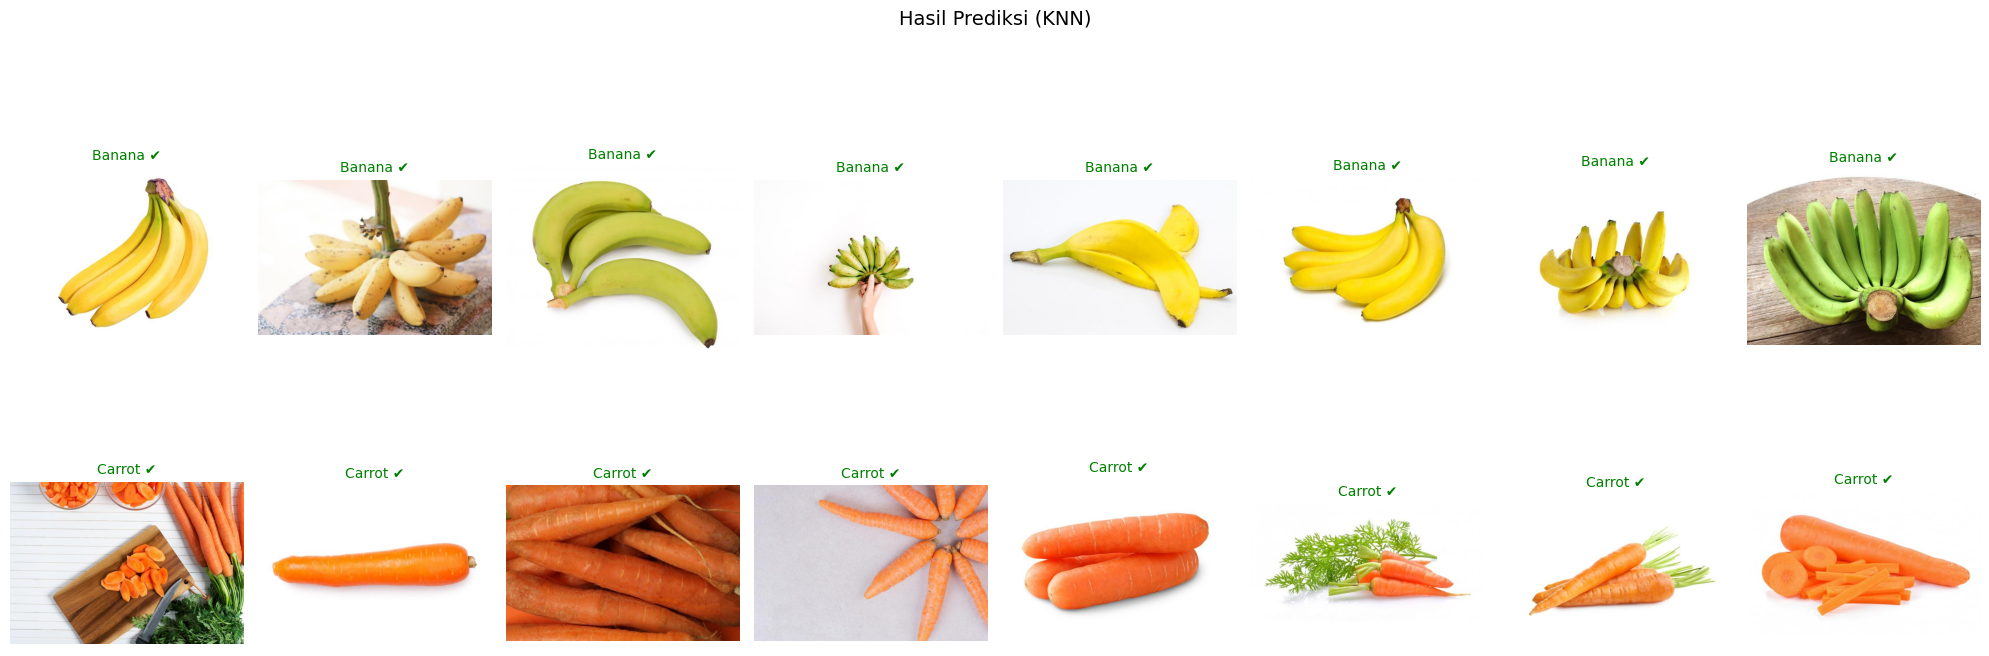

In [13]:
def show_correct_predictions(paths, y_true, y_pred, n_each=8):
    paths = paths.reset_index(drop=True)
    y_true = y_true.reset_index(drop=True)

    banana_idx = []
    carrot_idx = []

    # ambil hanya yang prediksi BENAR
    for i in range(len(y_true)):
        if y_true.iloc[i] == y_pred[i]:
            if y_true.iloc[i] == 1 and len(banana_idx) < n_each:
                banana_idx.append(i)
            elif y_true.iloc[i] == 0 and len(carrot_idx) < n_each:
                carrot_idx.append(i)

    plt.figure(figsize=(20, 8))

    # ===== BARIS ATAS → BANANA =====
    for i, idx in enumerate(banana_idx):
        plt.subplot(2, n_each, i + 1)

        img = cv2.imread(paths.iloc[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title("Banana ✔", fontsize=10, color='green')
        plt.axis("off")

    # ===== BARIS BAWAH → CARROT =====
    for i, idx in enumerate(carrot_idx):
        plt.subplot(2, n_each, n_each + i + 1)

        img = cv2.imread(paths.iloc[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title("Carrot ✔", fontsize=10, color='green')
        plt.axis("off")

    plt.suptitle("Hasil Prediksi (KNN)", fontsize=14)
    plt.tight_layout()
    plt.show()


# ==========================
# PANGGIL
# ==========================
show_correct_predictions(path_test, y_test, y_pred, n_each=8)

# **14. VISUALISASI DATA**

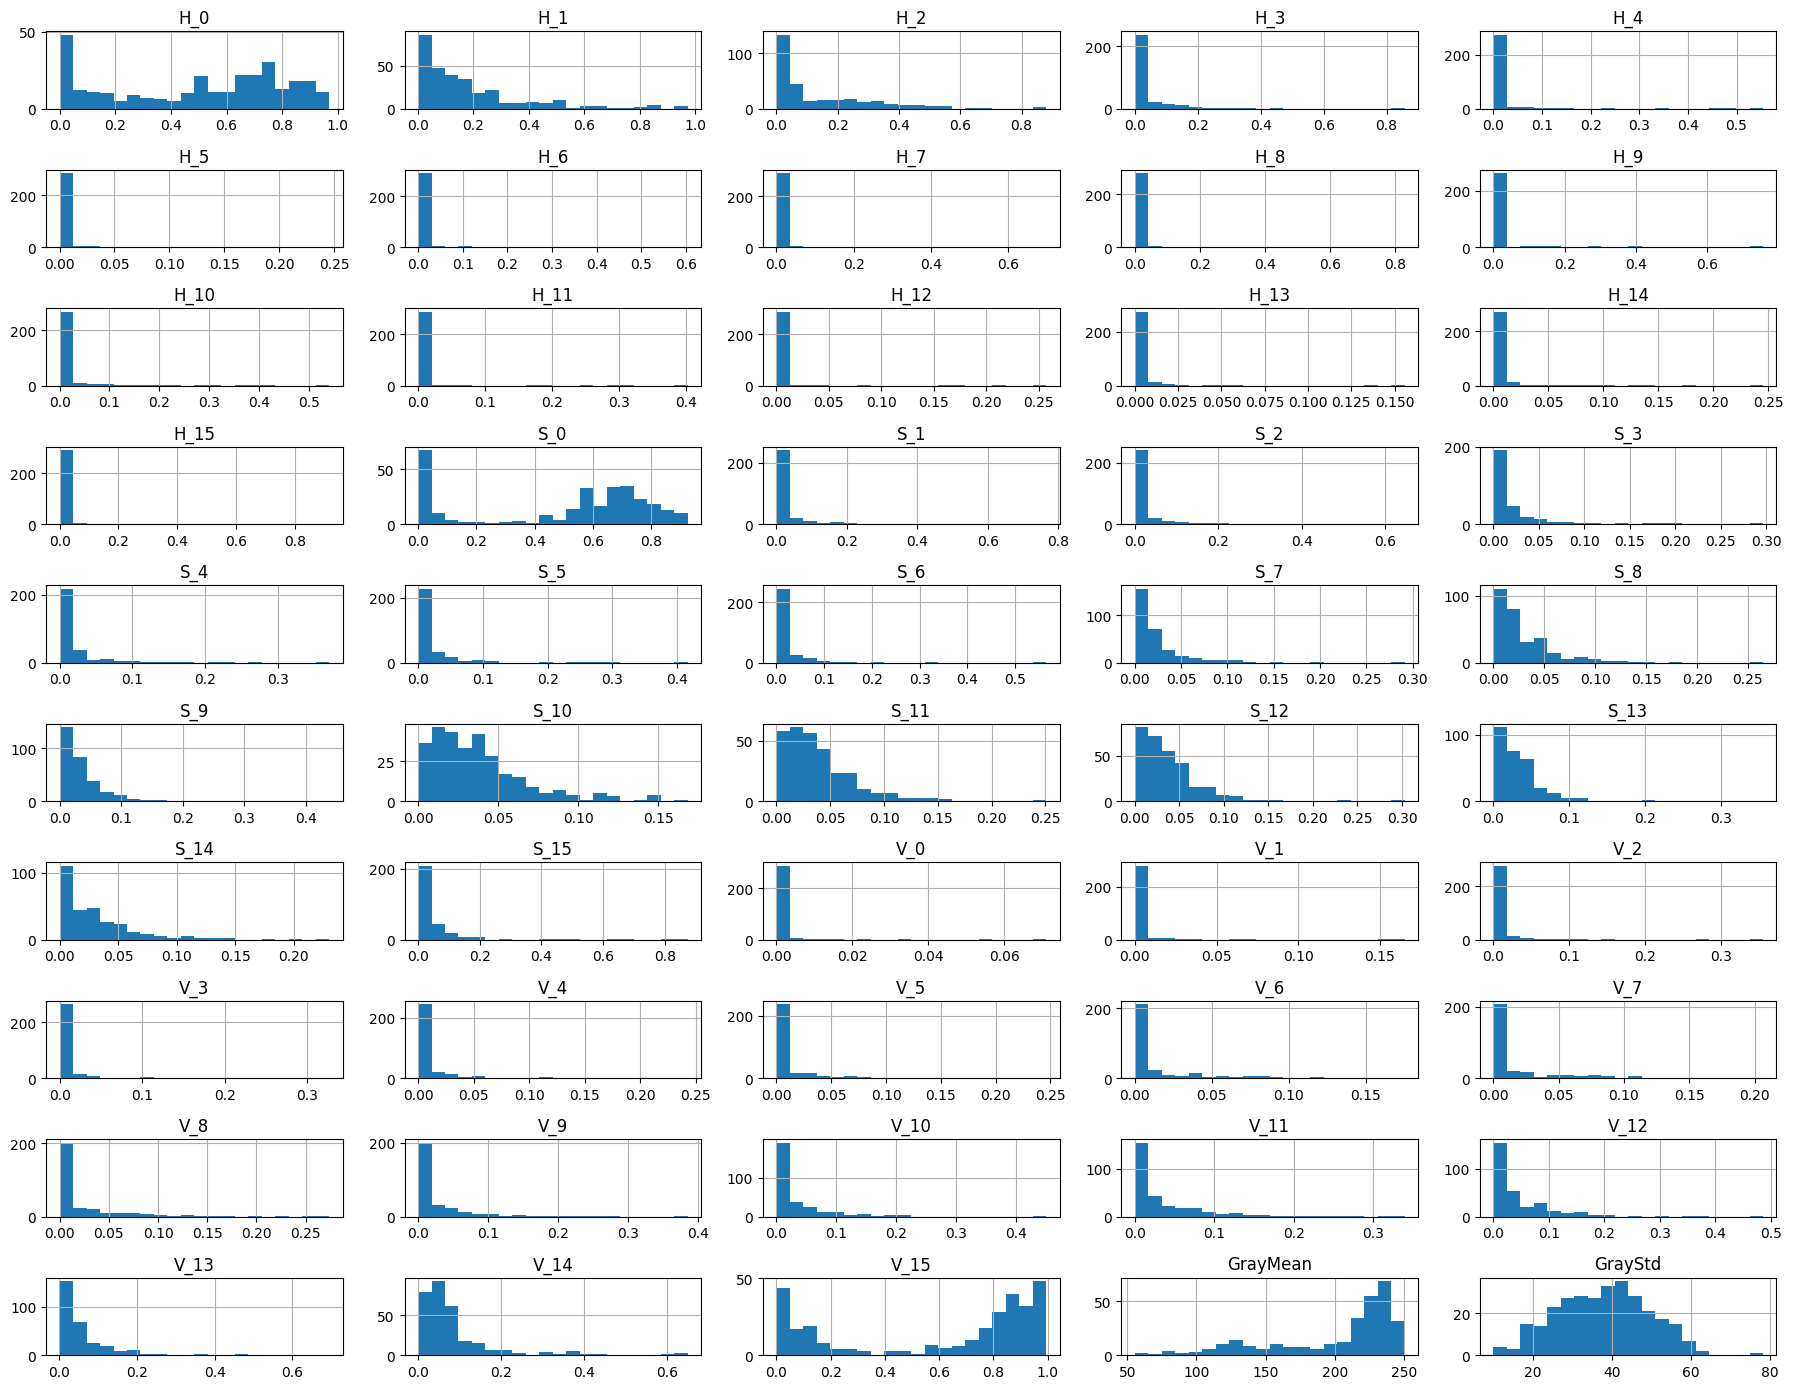

In [14]:
df.drop(columns=["Label","Path"]).hist(
    figsize=(18,14),   # diperbesar
    bins=20,           # lebih halus
    layout=(10,5)      # atur grid (biar rapi)
)

plt.tight_layout()
plt.show()